In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import os

In [2]:
df = pd.read_csv(os.path.join("..", "data", "processed", "training_data.csv"))

display(df.head())

,driver_id,signup_date,avg_rating,current_tier,Churned,avg_earnings_per_hour_online,trip_utilization_rate,surge_reliance_score,is_premium_capable,premium_trip_ratio,peak_hour_driver_score,session_regularity,quest_completion_rate,incentive_reliance_pct,pro_tier_status,cancellation_rate,acceptance_rate
0,5729981b-bf65-48ac-a418-95693a8d26ef,2025-07-16 08:43:42.076226-04:00,4.84,Blue,0,12.716965,0.429709,0.078188,0,0.000000,0.481818,89.034310,0.000000,0.000000,3,0.130137,0.666667
1,caf9988b-9ff9-4dcc-b9a5-4d6953ac8a0b,2025-11-04 02:36:10.076226-05:00,4.80,Platinum,0,17.065534,0.525368,0.102074,0,0.000000,0.476112,3.705339,0.875000,0.115524,1,0.102744,0.851168
2,5d9761b2-ee05-4923-98ca-1f16a4a6df73,2025-06-27 03:06:08.076226-04:00,4.91,Diamond,0,31.851693,0.419952,0.150102,1,0.806924,0.439414,30.094497,0.166667,0.005854,0,0.022485,0.497644
3,0a298bab-317f-49f7-a021-432c6cf80366,2025-10-18 22:08:13.076226-04:00,4.94,Platinum,0,31.627454,0.400830,0.183966,1,0.798283,0.419170,9.303206,0.166667,0.004039,1,0.014570,0.495407
4,5843b2fc-ffa0-4cd2-a0bc-c950eecab4f0,2025-08-14 01:17:21.076226-04:00,4.72,Blue,1,12.421348,0.400394,0.125967,0,0.000000,0.414894,57.364287,0.000000,0.000000,3,0.170732,0.584323


In [3]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581 entries, 0 to 580
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   driver_id                     581 non-null    object 
 1   signup_date                   581 non-null    object 
 2   avg_rating                    581 non-null    float64
 3   current_tier                  581 non-null    object 
 4   Churned                       581 non-null    int64  
 5   avg_earnings_per_hour_online  581 non-null    float64
 6   trip_utilization_rate         581 non-null    float64
 7   surge_reliance_score          581 non-null    float64
 8   is_premium_capable            581 non-null    int64  
 9   premium_trip_ratio            581 non-null    float64
 10  peak_hour_driver_score        581 non-null    float64
 11  session_regularity            581 non-null    float64
 12  quest_completion_rate         581 non-null    float64
 13  incen

None

In [4]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
avg_rating,581.0,4.829793,0.105952,4.500000,4.770000,4.840000,4.910000,5.000000
Churned,581.0,0.311532,0.463519,0.000000,0.000000,0.000000,1.000000,1.000000
avg_earnings_per_hour_online,581.0,18.329754,8.030268,2.628440,12.189479,16.999168,23.106769,35.734586
trip_utilization_rate,581.0,0.451808,0.110951,0.099008,0.400216,0.506010,0.528629,0.576195
surge_reliance_score,581.0,0.144240,0.086984,0.000000,0.091317,0.106002,0.182668,0.321931
is_premium_capable,581.0,0.165232,0.371710,0.000000,0.000000,0.000000,0.000000,1.000000
premium_trip_ratio,581.0,0.132155,0.297370,0.000000,0.000000,0.000000,0.000000,0.843206
peak_hour_driver_score,581.0,0.449303,0.068350,0.000000,0.419170,0.444444,0.475297,0.818182
session_regularity,581.0,32.539285,40.358492,1.051286,10.965351,22.001120,35.369215,375.844334
quest_completion_rate,581.0,0.464276,0.379425,0.000000,0.083333,0.500000,0.866667,1.000000


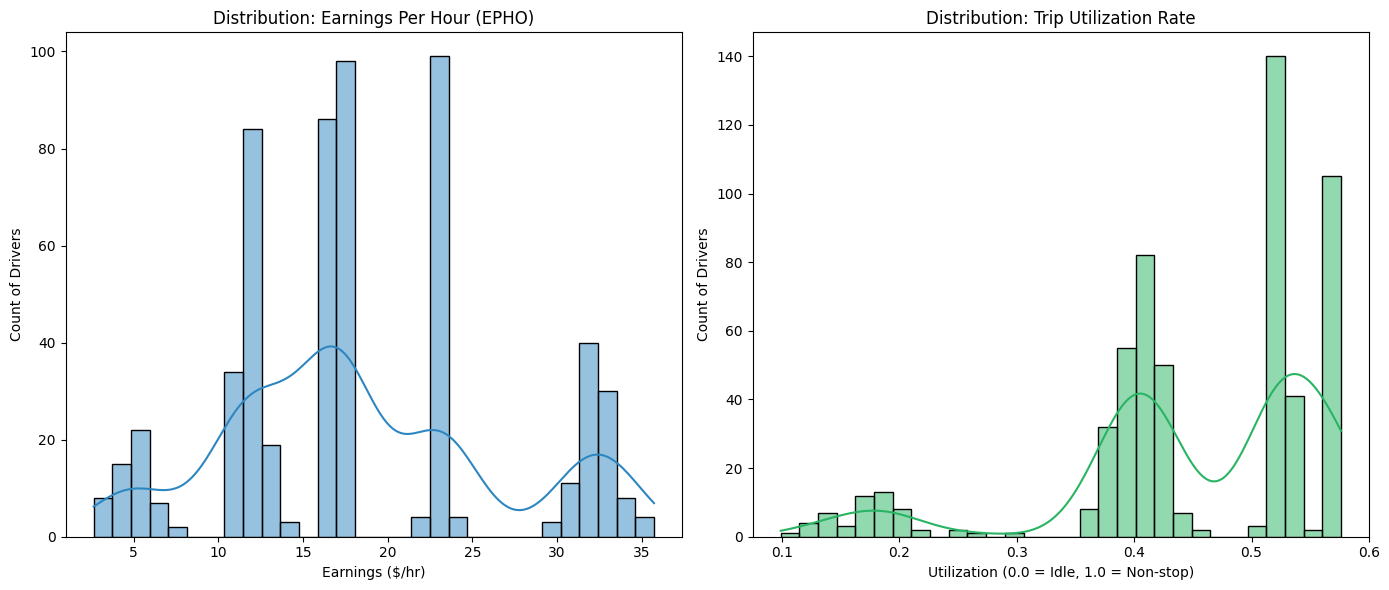

In [5]:
# Set up the figure size
plt.figure(figsize=(14, 6))

# Plot 1: EPHO (Earnings Per Hour Online)
plt.subplot(1, 2, 1)
sns.histplot(df['avg_earnings_per_hour_online'], kde=True, bins=30, color='#2E86C1')
plt.title('Distribution: Earnings Per Hour (EPHO)')
plt.xlabel('Earnings ($/hr)')
plt.ylabel('Count of Drivers')

# Plot 2: Trip Utilization Rate
plt.subplot(1, 2, 2)
sns.histplot(df['trip_utilization_rate'], kde=True, bins=30, color='#28B463')
plt.title('Distribution: Trip Utilization Rate')
plt.xlabel('Utilization (0.0 = Idle, 1.0 = Non-stop)')
plt.ylabel('Count of Drivers')

plt.tight_layout()
plt.show()


The visualization of the data shows the the data is Multi-Modal - which is very good for analysis. 

We don't need to apply complex Log Transformations here because the data is already beautifully separated.


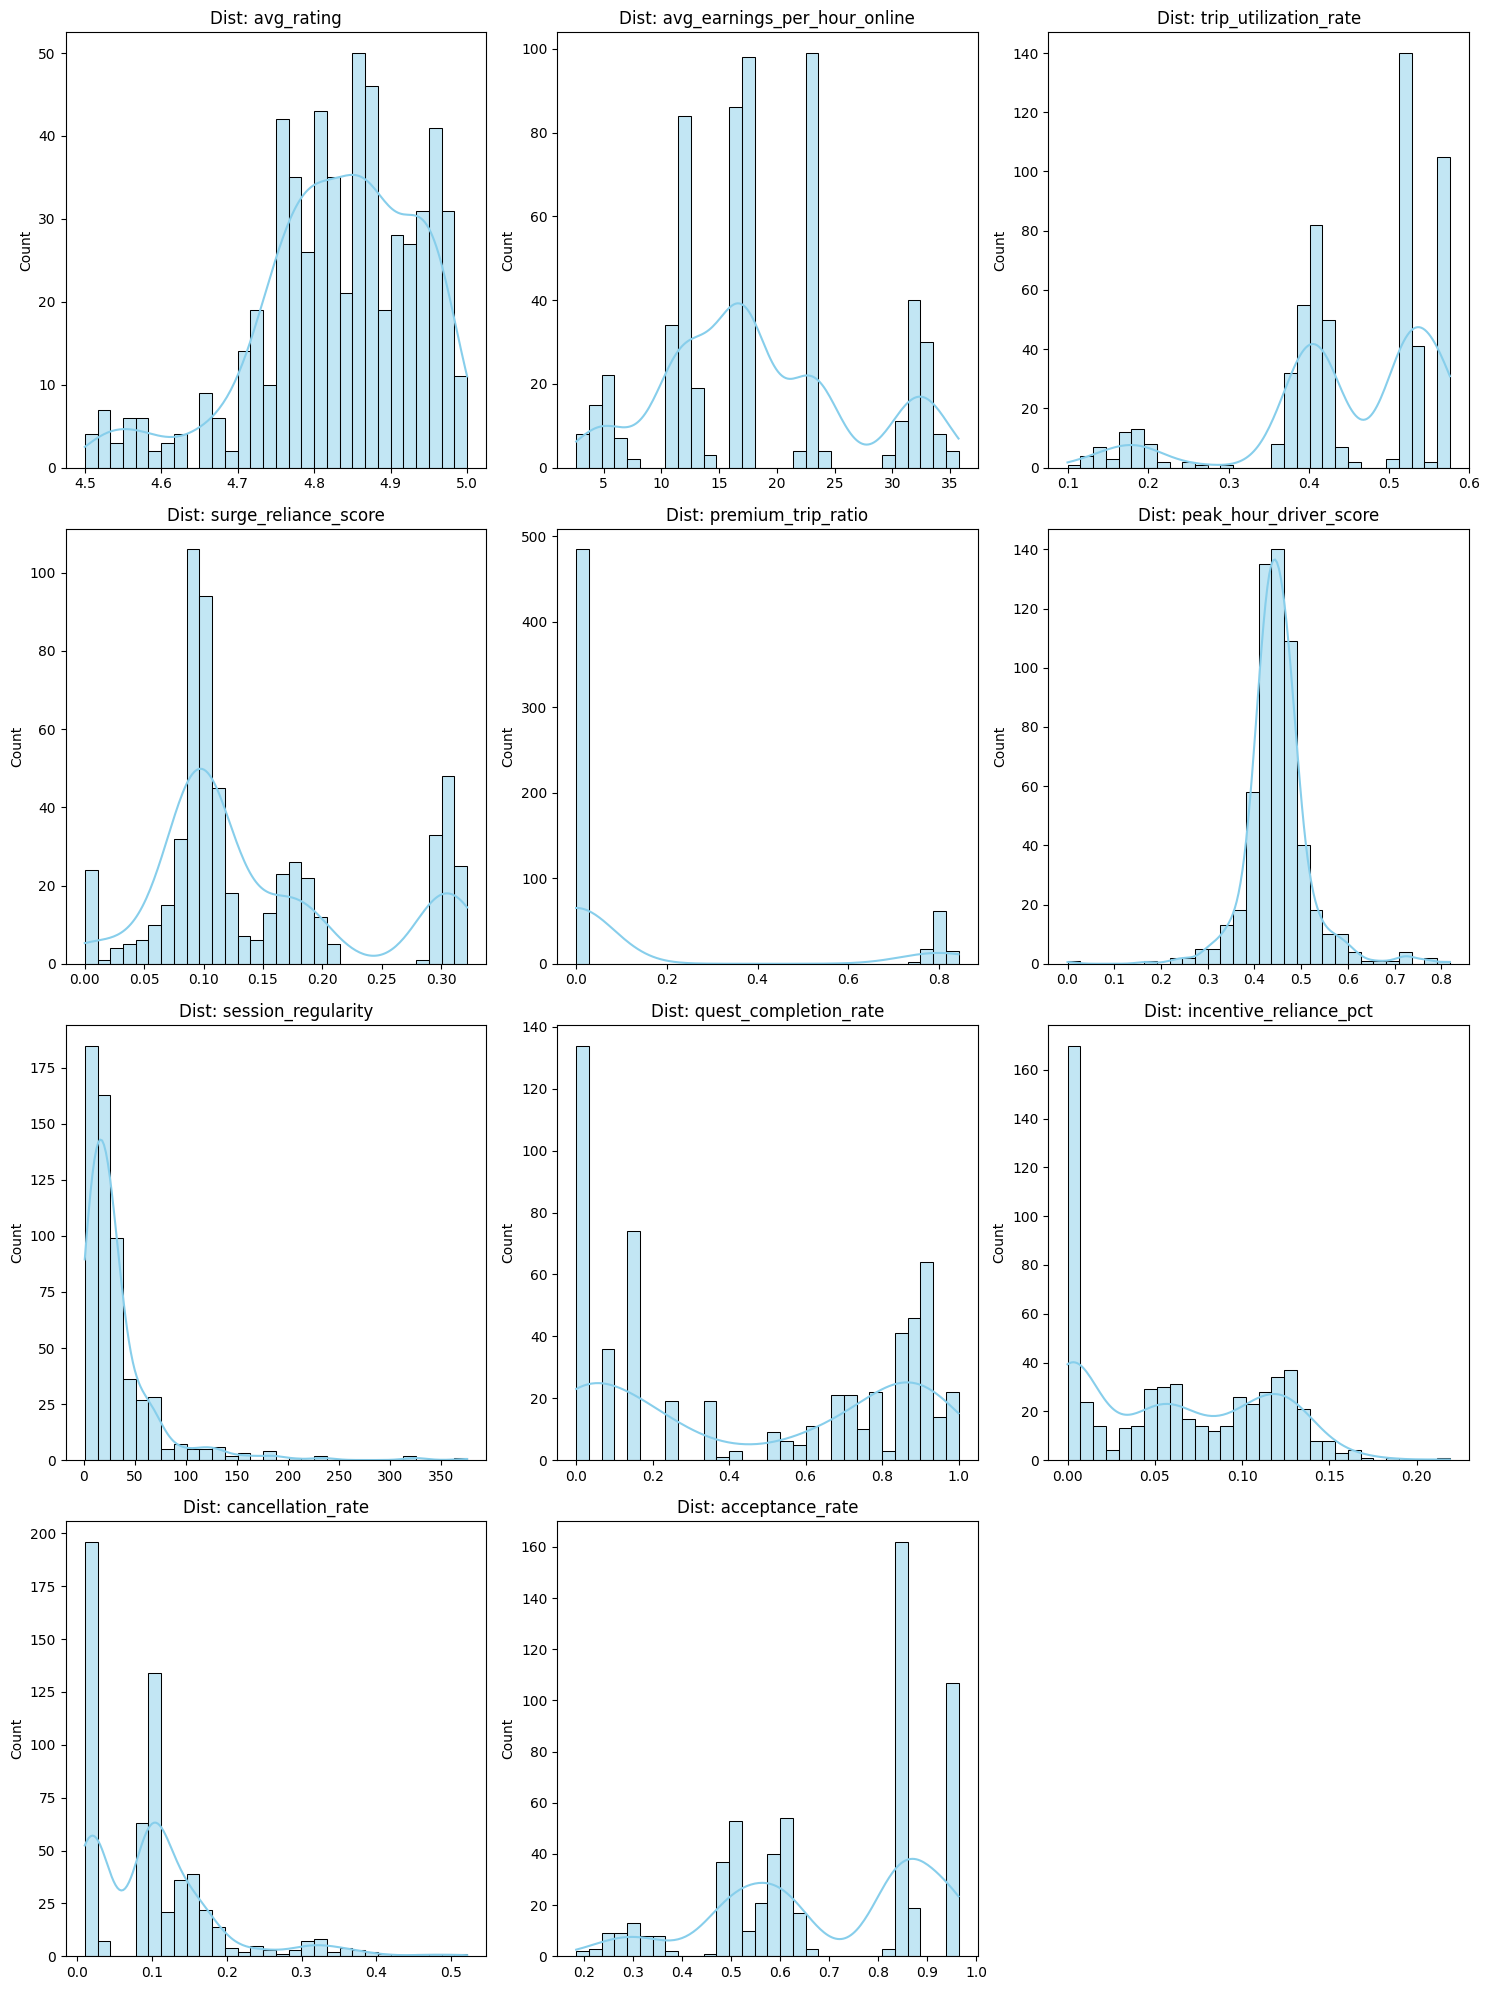

In [6]:
# Get all numerical columns (excluding ID and Churned targets)
numeric_cols = df.select_dtypes(include=['float64', 'float32', 'int64']).columns
cols_to_plot = [c for c in numeric_cols if c not in ['driver_id', 'Churned', 'pro_tier_status', 'is_premium_capable']]

# Calculate grid size (rows needed)
n_cols = 3
n_rows = (len(cols_to_plot) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols_to_plot):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Dist: {col}')
    plt.xlabel('')
    
plt.tight_layout()
plt.show()

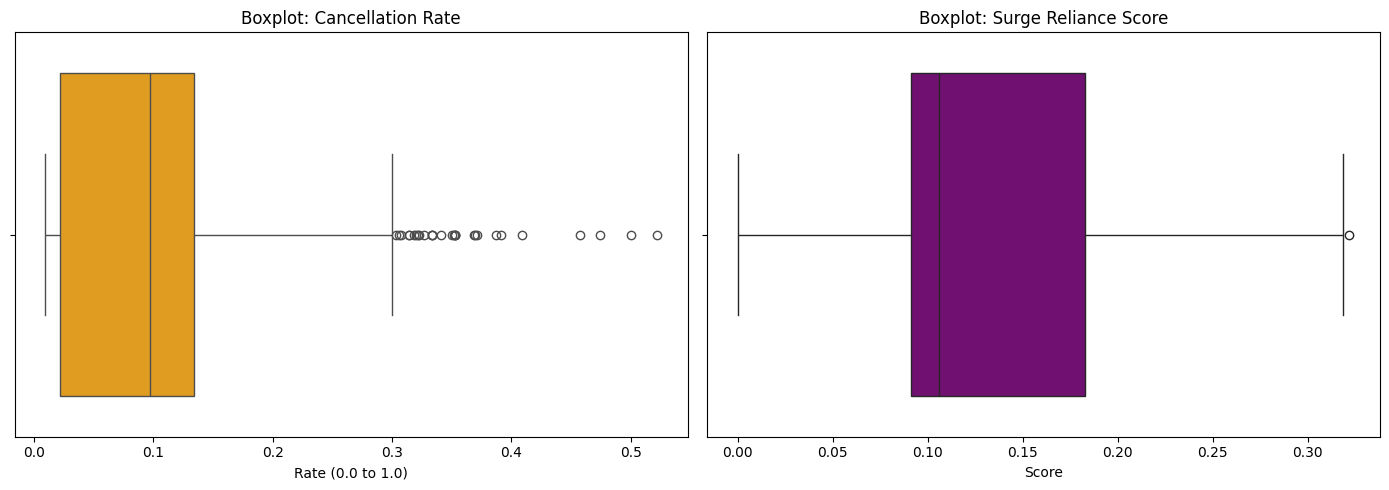

In [7]:
# Set up the figure size
plt.figure(figsize=(14, 5))

# Plot 1: Cancellation Rate Outliers
plt.subplot(1, 2, 1)
# Fix: Ensure numeric and drop NaNs
clean_cancel_data = pd.to_numeric(df['cancellation_rate'], errors='coerce').dropna()
sns.boxplot(x=clean_cancel_data, color='orange')
plt.title('Boxplot: Cancellation Rate')
plt.xlabel('Rate (0.0 to 1.0)')

# Plot 2: Surge Reliance Outliers
plt.subplot(1, 2, 2)
# Fix: Ensure numeric and drop NaNs
clean_surge_data = pd.to_numeric(df['surge_reliance_score'], errors='coerce').dropna()
sns.boxplot(x=clean_surge_data, color='purple')
plt.title('Boxplot: Surge Reliance Score')
plt.xlabel('Score')

plt.tight_layout()
plt.show()

Its interesting to see so many outliers for cancellation rate. Although usually outliers need to be dealt with, in a Cohort and Churn Analysis situation, it might be helpful to let the outliers be as it might be helpful in defining how some users interact with the Uber Driver App. 
*Note to Self: use robust-scaling while implementing k-means to avoid any problems*

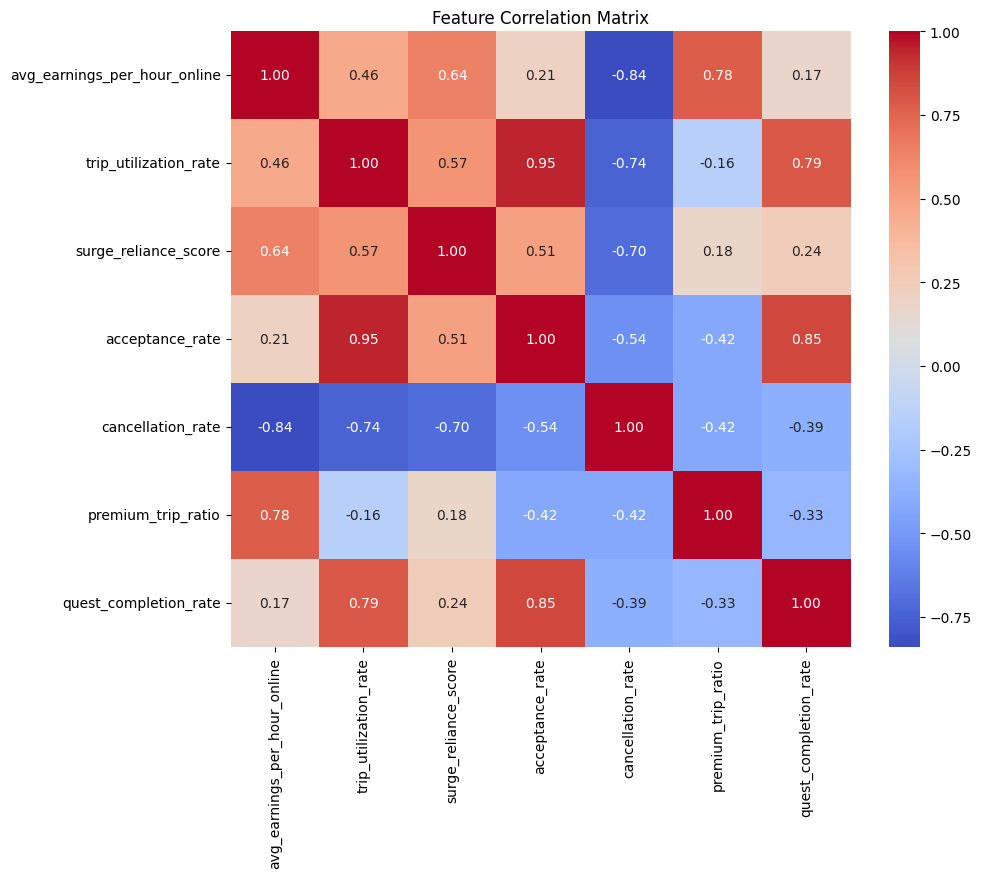

In [8]:
# Compute the correlation matrix
corr_matrix = df[['avg_earnings_per_hour_online', 'trip_utilization_rate', 'surge_reliance_score', 'acceptance_rate', 'cancellation_rate', 'premium_trip_ratio','quest_completion_rate']].corr()

# Set up the figure
plt.figure(figsize=(10, 8))

# Draw the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f",cmap='coolwarm')

plt.title('Feature Correlation Matrix')
plt.show()

### Action Items

1. trip_utilization_rate and acceptance_rate are highly correlated (the more work you accept - the more work you get). Deleting acceptance rate might actually be helpful to avoid multicollinearity (for K-means). For XGBoost, we can keep both of them.

Other observations: 

higher cancellation means lower EPHO and also lower utlization rate. the algorithm either penalizes you or you're not moving enough to make money

drivers who take premium trips only tend to have lower acceptance rate


C:\Users\burha\AppData\Local\Temp\ipykernel_52872\158112737.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churned', y='avg_earnings_per_hour_online', data=df, palette='Set2')
C:\Users\burha\AppData\Local\Temp\ipykernel_52872\158112737.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churned', y='trip_utilization_rate', data=df, palette='Set2')


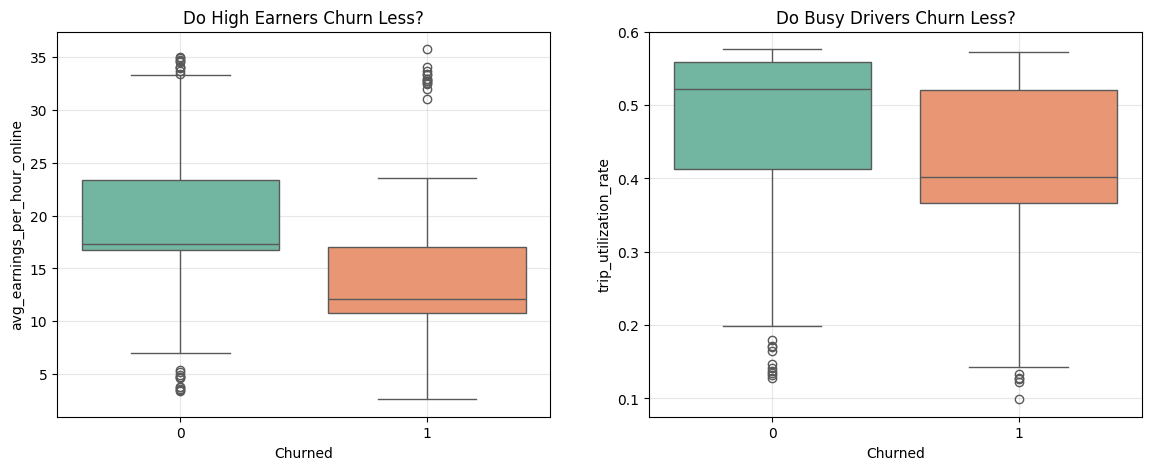

In [9]:
# Set up the figure
plt.figure(figsize=(14, 5))

# Plot 1: Earnings vs Churn
plt.subplot(1, 2, 1)
sns.boxplot(x='Churned', y='avg_earnings_per_hour_online', data=df, palette='Set2')
plt.title('Do High Earners Churn Less?')
plt.grid(True, alpha=0.3)

# Plot 2: Utilization vs Churn
plt.subplot(1, 2, 2)
sns.boxplot(x='Churned', y='trip_utilization_rate', data=df, palette='Set2')
plt.title('Do Busy Drivers Churn Less?')
plt.grid(True, alpha=0.3)

plt.show()

High earnings reduce churn risk, but they don't eliminate it. If a driver sits in their car for 40 minutes without a ping, they quit. Also interesting to see a lot of outliers. There are a lot of churned drivers who earned pretty good and/or are pretty busy - indicating other factors like burn out, better job opportunities etc
